In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Ear Diseases/Dataset"

'Ear diseases and Segmentation.zip'   extracted


In [ ]:
!rm -rf /content/ear_dataset
!cp -r "/content/drive/MyDrive/Ear Diseases/Dataset/extracted" /content/ear_dataset


In [ ]:
!ls /content/ear_dataset


test  train  valid


In [ ]:
!ls /content/ear_dataset/train | head


_annotations_clean.coco.json
_annotations.coco.json
aom-100-_jpg.rf.8cf2f9492adac29e930d5f069f6d42d2.jpg
aom-101-_jpg.rf.1c433dfaedc724d6f45a1184fd3d0135.jpg
aom-102-_jpg.rf.d8f0005b1d36b2fd54c2af1974fd6d92.jpg
aom-103-_jpg.rf.139971e70ab0aca3bad3af8894535197.jpg
aom-106-_jpg.rf.c7731b7e90a1741dab5969e488ce7019.jpg
aom-107-_jpg.rf.ab71698aa096b4590bd2cba0ab14aecc.jpg
aom-109-_jpg.rf.8be98aad699b7b995abd0fd4dccc8c98.jpg
aom-110-_jpg.rf.b1c0db2d23baadd4e71e10a50ba0799c.jpg


In [ ]:
import json

ann_path = "/content/ear_dataset/train/_annotations.coco.json"

with open(ann_path) as f:
    data = json.load(f)

categories = [c['name'] for c in data['categories']]
print("Classes in dataset:", categories)


Classes in dataset: ['ear_conditions-zL5Z', 'aom', 'ci', 'com', 'mys', 'norm']


In [ ]:
import json
import os

ann_path = "/content/ear_dataset/train/_annotations.coco.json"
new_ann_path = "/content/ear_dataset/train/_annotations_filtered.coco.json"

with open(ann_path) as f:
    data = json.load(f)

filtered_categories = [c for c in data['categories'] if c['name'] != 'ear_conditions-zL5Z']
data['categories'] = filtered_categories

valid_ids = [c['id'] for c in filtered_categories]

data['annotations'] = [a for a in data['annotations'] if a['category_id'] in valid_ids]

with open(new_ann_path, "w") as f:
    json.dump(data, f)

print("Filtered annotation saved.")


Filtered annotation saved.


In [ ]:
with open("/content/ear_dataset/train/_annotations_filtered.coco.json") as f:
    data = json.load(f)

print([c['name'] for c in data['categories']])


['aom', 'ci', 'com', 'mys', 'norm']


## **Binary class Mapping**

In [ ]:
import os, json, shutil
from collections import defaultdict

base_dir = "/content/ear_dataset"
binary_dir = "/content/binary_dataset"

splits = ["train", "valid", "test"]

for split in splits:
    os.makedirs(f"{binary_dir}/{split}/Normal", exist_ok=True)
    os.makedirs(f"{binary_dir}/{split}/Abnormal", exist_ok=True)

    ann_path = f"{base_dir}/{split}/_annotations.coco.json"

    if split == "train":
        ann_path = f"{base_dir}/{split}/_annotations_filtered.coco.json"

    with open(ann_path) as f:
        data = json.load(f)

    cat_map = {c['id']: c['name'] for c in data['categories']}

    img_map = {img['id']: img['file_name'] for img in data['images']}

    img_labels = defaultdict(set)
    for ann in data['annotations']:
        img_labels[ann['image_id']].add(cat_map[ann['category_id']])

    for img_id, labels in img_labels.items():
        file_name = img_map[img_id]
        src = f"{base_dir}/{split}/{file_name}"

        if "norm" in labels and len(labels) == 1:
            dst = f"{binary_dir}/{split}/Normal/{file_name}"
        else:
            dst = f"{binary_dir}/{split}/Abnormal/{file_name}"

        if os.path.exists(src):
            shutil.copy(src, dst)

print("Binary dataset created successfully!")


Binary dataset created successfully!


In [ ]:
!ls /content/binary_dataset/train

Abnormal  Normal


In [ ]:
normal_count = len(os.listdir("/content/binary_dataset/train/Normal"))
abnormal_count = len(os.listdir("/content/binary_dataset/train/Abnormal"))

print(f"Normal: {normal_count}")
print(f"Abnormal: {abnormal_count}")


Normal: 469
Abnormal: 1869


In [ ]:
import os

save_root = "/content/drive/MyDrive/EarProject"
os.makedirs(save_root, exist_ok=True)

!cp -r /content/binary_dataset /content/drive/MyDrive/EarProject/

print("Binary dataset saved permanently in Drive")


^C
Binary dataset saved permanently in Drive


## **Multi class Mapping**

In [ ]:
import os, json, shutil
from collections import defaultdict

base_dir = "/content/ear_dataset"
multi_dir = "/content/multiclass_dataset"

splits = ["train", "valid", "test"]

disease_map = {
    "aom": "AOM",
    "ci": "CI",
    "com": "COM",
    "mys": "MYS"
}

for split in splits:
    for d in disease_map.values():
        os.makedirs(f"{multi_dir}/{split}/{d}", exist_ok=True)

    ann_path = f"{base_dir}/{split}/_annotations.coco.json"
    if split == "train":
        ann_path = f"{base_dir}/{split}/_annotations_filtered.coco.json"

    with open(ann_path) as f:
        data = json.load(f)

    cat_map = {c['id']: c['name'] for c in data['categories']}
    img_map = {img['id']: img['file_name'] for img in data['images']}

    img_labels = defaultdict(set)
    for ann in data['annotations']:
        img_labels[ann['image_id']].add(cat_map[ann['category_id']])

    for img_id, labels in img_labels.items():
        file_name = img_map[img_id]
        src = f"{base_dir}/{split}/{file_name}"

        diseases = [l for l in labels if l in disease_map]

        if len(diseases) == 1:
            dst = f"{multi_dir}/{split}/{disease_map[diseases[0]]}/{file_name}"
            if os.path.exists(src):
                shutil.copy(src, dst)

print("Multiclass dataset created!")


Multiclass dataset created!


In [ ]:
!ls /content/multiclass_dataset/train


AOM  CI  COM  MYS


In [ ]:
for cls in ["AOM", "CI", "COM", "MYS"]:
    count = len(os.listdir(f"/content/multiclass_dataset/train/{cls}"))
    print(f"{cls}: {count}")


AOM: 420
CI: 474
COM: 484
MYS: 491


In [ ]:
import os

save_root = "/content/drive/MyDrive/EarProject"
os.makedirs(save_root, exist_ok=True)

!cp -r /content/multiclass_dataset /content/drive/MyDrive/EarProject/

print("Multiclass dataset saved permanently in Drive")


^C
Multiclass dataset saved permanently in Drive


### **RESNET18 PIPELINE — BINARY CLASSIFICATION**

In [ ]:
!pip install -q timm

import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
from PIL import Image
import os

def remove_corrupted_images(folder):
    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                print("Removing corrupted:", path)
                os.remove(path)

remove_corrupted_images("/content/binary_dataset")
print("Cleaning done")


Removing corrupted: /content/binary_dataset/train/Abnormal/aom-366-_jpg.rf.26b5e09a41dd09a5d0c72e82018b6a57.jpg
Cleaning done


In [ ]:
# Image Transformers
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("Transforms created")


Transforms created


In [ ]:
# Loading Binary dataset
train_dir = "/content/binary_dataset/train"
val_dir = "/content/binary_dataset/valid"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))


Classes: ['Abnormal', 'Normal']
Class to index: {'Abnormal': 0, 'Normal': 1}
Train size: 2337
Val size: 292


In [ ]:
# Creating Dataloaders
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)


val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 74
Val batches: 10


In [ ]:
# Creating Binary model
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

print("ResNet18 Baseline model ready")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]


ResNet18 Baseline model ready


In [ ]:
for name, param in model.named_parameters():
    if "fc" not in name:
        param.requires_grad = False


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0005
)
print("Loss and Optimizer ready")


Loss and Optimizer ready


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    # TRAINING
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    # VALIDATION
    model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accuracy = 100 * correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"- Train Loss: {train_loss:.4f} "
          f"- Train Acc: {train_accuracy:.2f}% "
          f"- Val Acc: {val_accuracy:.2f}%")


Epoch [1/10] - Train Loss: 0.4057 - Train Acc: 80.40% - Val Acc: 75.68%
Epoch [2/10] - Train Loss: 0.3165 - Train Acc: 84.12% - Val Acc: 85.27%
Epoch [3/10] - Train Loss: 0.3008 - Train Acc: 87.85% - Val Acc: 90.41%
Epoch [4/10] - Train Loss: 0.2627 - Train Acc: 88.40% - Val Acc: 89.38%
Epoch [5/10] - Train Loss: 0.2342 - Train Acc: 90.12% - Val Acc: 89.04%
Epoch [6/10] - Train Loss: 0.2153 - Train Acc: 91.10% - Val Acc: 83.90%
Epoch [7/10] - Train Loss: 0.2042 - Train Acc: 92.13% - Val Acc: 89.38%
Epoch [8/10] - Train Loss: 0.2519 - Train Acc: 91.14% - Val Acc: 85.27%
Epoch [9/10] - Train Loss: 0.2079 - Train Acc: 91.87% - Val Acc: 88.01%
Epoch [10/10] - Train Loss: 0.1969 - Train Acc: 92.08% - Val Acc: 87.33%


In [ ]:
# Load Test Dataset
test_dir = "/content/binary_dataset/test"
test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Total Test Samples: {total}")
print(f"Correct Predictions: {correct}")
print(f"Test Accuracy: {test_accuracy:.2f}%")


Total Test Samples: 292
Correct Predictions: 276
Test Accuracy: 94.52%


In [ ]:
import os

save_dir = "/content/drive/MyDrive/EarProject/models"
os.makedirs(save_dir, exist_ok=True)

print("Folder ready")


Folder ready


In [ ]:
torch.save(model.state_dict(),
           "/content/drive/MyDrive/EarProject/models/resnet18_binary_best.pth")

print("Resnet Binary Model saved successfully!")


Resnet Binary Model saved successfully!


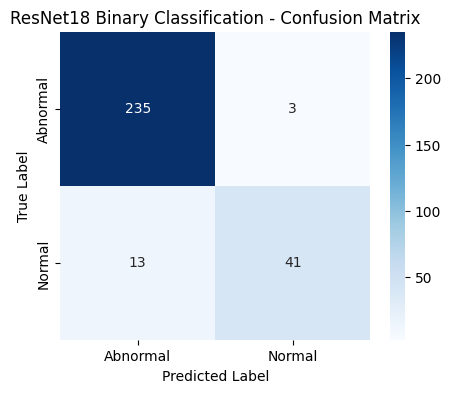


Classification Report:

              precision    recall  f1-score   support

    Abnormal       0.95      0.99      0.97       238
      Normal       0.93      0.76      0.84        54

    accuracy                           0.95       292
   macro avg       0.94      0.87      0.90       292
weighted avg       0.94      0.95      0.94       292



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet18 Binary Classification - Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,
                            target_names=test_dataset.classes))


**RESNET18 PIPELINE — MULTICLASS CLASSIFICATION**

In [ ]:
# Cleaning corrupted images
from PIL import Image
import os

def remove_corrupted_images(folder):
    removed = 0
    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                print("Removing corrupted:", path)
                os.remove(path)
                removed += 1
    print("Total removed:", removed)

remove_corrupted_images("/content/multiclass_dataset")


Removing corrupted: /content/multiclass_dataset/train/AOM/aom-366-_jpg.rf.26b5e09a41dd09a5d0c72e82018b6a57.jpg
Total removed: 1


In [ ]:
# Multi-class dataset paths
train_dir_multi = "/content/multiclass_dataset/train"
val_dir_multi = "/content/multiclass_dataset/valid"

train_dataset_multi = datasets.ImageFolder(train_dir_multi, transform=train_transforms)
val_dataset_multi = datasets.ImageFolder(val_dir_multi, transform=val_transforms)

print("Classes:", train_dataset_multi.classes)
print("Class to index:", train_dataset_multi.class_to_idx)
print("Train size:", len(train_dataset_multi))
print("Validation size:", len(val_dataset_multi))


Classes: ['AOM', 'CI', 'COM', 'MYS']
Class to index: {'AOM': 0, 'CI': 1, 'COM': 2, 'MYS': 3}
Train size: 1868
Validation size: 215


In [ ]:
# Creating Dataloaders
batch_size = 32

train_loader_multi = DataLoader(
    train_dataset_multi,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader_multi = DataLoader(
    val_dataset_multi,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader_multi))
print("Validation batches:", len(val_loader_multi))


Train batches: 59
Validation batches: 7


In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

model_multi = resnet18(weights=ResNet18_Weights.DEFAULT)

num_features = model_multi.fc.in_features
model_multi.fc = nn.Linear(num_features, 4)

for param in model_multi.parameters():
    param.requires_grad = False

for name, param in model_multi.named_parameters():
    if "fc" in name:
        param.requires_grad = True


model_multi = model_multi.to(device)

print("ResNet18 Multi-class model ready")


ResNet18 Multi-class model ready


In [ ]:
# Loss function and Optimizer
criterion_multi = nn.CrossEntropyLoss()

optimizer_multi = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_multi.parameters()),
    lr=0.0005
)

print("Loss and Optimizer for Multi-class ready")


Loss and Optimizer for Multi-class ready


In [ ]:
num_epochs = 10
best_val_acc = 0

for epoch in range(num_epochs):

    # TRAINING
    model_multi.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader_multi:
        images, labels = images.to(device), labels.to(device)

        optimizer_multi.zero_grad()
        outputs = model_multi(images)
        loss = criterion_multi(outputs, labels)
        loss.backward()
        optimizer_multi.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader_multi)
    train_accuracy = 100 * correct_train / total_train

    # VALIDATION
    model_multi.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader_multi:
            images, labels = images.to(device), labels.to(device)
            outputs = model_multi(images)
            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accuracy = 100 * correct_val / total_val


    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model_multi.state_dict(),
                   "/content/drive/MyDrive/EarProject/models/resnet18_multiclass_best.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"- Train Loss: {train_loss:.4f} "
          f"- Train Acc: {train_accuracy:.2f}% "
          f"- Val Acc: {val_accuracy:.2f}%")

print("Best Validation Accuracy:", best_val_acc)


Epoch [1/10] - Train Loss: 0.9173 - Train Acc: 69.65% - Val Acc: 84.19%
Epoch [2/10] - Train Loss: 0.4318 - Train Acc: 92.24% - Val Acc: 88.84%
Epoch [3/10] - Train Loss: 0.3018 - Train Acc: 94.81% - Val Acc: 91.63%
Epoch [4/10] - Train Loss: 0.2199 - Train Acc: 96.57% - Val Acc: 93.49%
Epoch [5/10] - Train Loss: 0.2024 - Train Acc: 95.88% - Val Acc: 89.30%
Epoch [6/10] - Train Loss: 0.1651 - Train Acc: 96.90% - Val Acc: 93.02%
Epoch [7/10] - Train Loss: 0.1476 - Train Acc: 97.06% - Val Acc: 93.02%
Epoch [8/10] - Train Loss: 0.1370 - Train Acc: 97.27% - Val Acc: 93.95%
Epoch [9/10] - Train Loss: 0.1314 - Train Acc: 97.75% - Val Acc: 93.95%
Epoch [10/10] - Train Loss: 0.1218 - Train Acc: 97.06% - Val Acc: 93.49%
Best Validation Accuracy: 93.95348837209302


In [ ]:
# Load Multi-class Test Dataset
test_dir_multi = "/content/multiclass_dataset/test"
test_dataset_multi = datasets.ImageFolder(test_dir_multi, transform=val_transforms)

test_loader_multi = DataLoader(test_dataset_multi, batch_size=32, shuffle=False)

model_multi.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader_multi:
        images, labels = images.to(device), labels.to(device)
        outputs = model_multi(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Total Test Samples: {total}")
print(f"Correct Predictions: {correct}")
print(f"Test Accuracy: {test_accuracy:.2f}%")


Total Test Samples: 238
Correct Predictions: 225
Test Accuracy: 94.54%


In [ ]:
torch.save(model_multi.state_dict(),
           "/content/drive/MyDrive/EarProject/models/resnet18_multiclass_best.pth")

print("ResNet18 Multi-class model saved successfully!")


ResNet18 Multi-class model saved successfully!


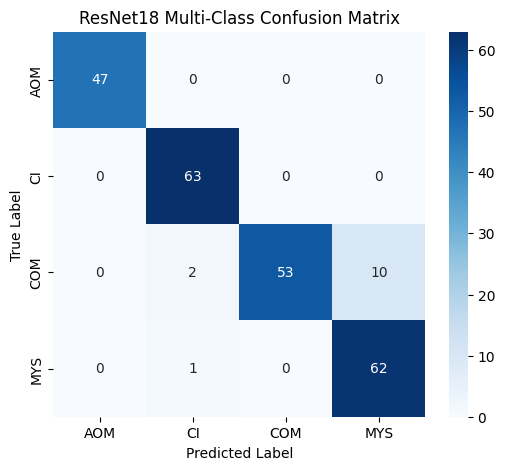


Classification Report:

              precision    recall  f1-score   support

         AOM       1.00      1.00      1.00        47
          CI       0.95      1.00      0.98        63
         COM       1.00      0.82      0.90        65
         MYS       0.86      0.98      0.92        63

    accuracy                           0.95       238
   macro avg       0.95      0.95      0.95       238
weighted avg       0.95      0.95      0.94       238



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_preds = []
all_labels = []

model_multi.eval()

with torch.no_grad():
    for images, labels in test_loader_multi:
        images = images.to(device)
        outputs = model_multi(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=test_dataset_multi.classes,
            yticklabels=test_dataset_multi.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet18 Multi-Class Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,
                            target_names=test_dataset_multi.classes))


In [ ]:
# Load Binary Model
from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights

binary_model = resnet18(weights=None)
binary_model.fc = nn.Linear(binary_model.fc.in_features, 2)
binary_model.load_state_dict(
    torch.load("/content/drive/MyDrive/EarProject/models/resnet18_binary_best.pth")
)
binary_model = binary_model.to(device)
binary_model.eval()

# Load Multi-class Model
multi_model = resnet18(weights=None)
multi_model.fc = nn.Linear(multi_model.fc.in_features, 4)
multi_model.load_state_dict(
    torch.load("/content/drive/MyDrive/EarProject/models/resnet18_multiclass_best.pth")
)
multi_model = multi_model.to(device)
multi_model.eval()

print("Both Binary and Multi-class models loaded successfully!")


Both Binary and Multi-class models loaded successfully!


In [ ]:
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

binary_classes = ['Abnormal', 'Normal']

multi_classes = [
    "Acute Otitis Media (AOM)",
    "Chronic Inflammation (CI)",
    "Chronic Otitis Media (COM)",
    "Myringosclerosis (MYS)"
]

def predict_image(image_path):

    # Display Image
    image = Image.open(image_path).convert("RGB")
    plt.imshow(image)
    plt.axis("off")
    plt.title("Input Ear Image")
    plt.show()

    # Transform image
    input_tensor = val_transforms(image).unsqueeze(0).to(device)

    # Binary Prediction
    with torch.no_grad():
        binary_output = binary_model(input_tensor)
        binary_probs = F.softmax(binary_output, dim=1)
        binary_confidence, binary_pred = torch.max(binary_probs, 1)

    binary_label = binary_classes[binary_pred.item()]
    binary_conf = binary_confidence.item() * 100

    print(f"\n Binary Prediction: {binary_label}")
    print(f" Confidence: {binary_conf:.2f}%")

    # If Normal → stop
    if binary_label == "Normal":
        print("\n No disease detected. Ear looks normal.")
        return

    # Multi-class Prediction
    with torch.no_grad():
        multi_output = multi_model(input_tensor)
        multi_probs = F.softmax(multi_output, dim=1)
        multi_confidence, multi_pred = torch.max(multi_probs, 1)

    multi_label = multi_classes[multi_pred.item()]
    multi_conf = multi_confidence.item() * 100

    print(f"\n Disease Type: {multi_label}")
    print(f" Disease Confidence: {multi_conf:.2f}%")


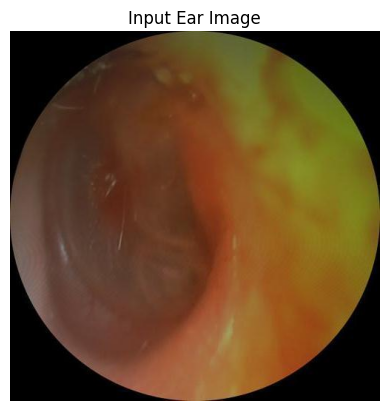


 Binary Prediction: Abnormal
 Confidence: 99.52%

 Disease Type: Acute Otitis Media (AOM)
 Disease Confidence: 99.64%


In [ ]:
image_path = "/content/multiclass_dataset/test/AOM/aom-113-_jpg.rf.c380dccd5dae162d26bc877cfd4e515a.jpg"
predict_image(image_path)

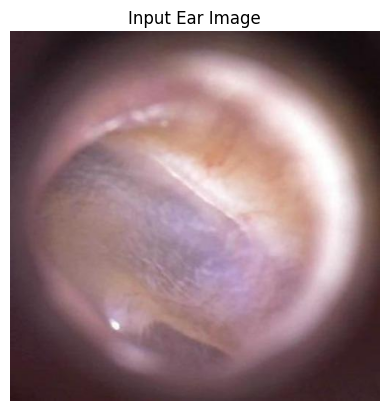


 Binary Prediction: Normal
 Confidence: 60.84%

 No disease detected. Ear looks normal.


In [ ]:
image_path = "/content/binary_dataset/test/Normal/norm-100-_jpg.rf.37750c24805443d2d1d1e94b104aefb4.jpg"

predict_image(image_path)


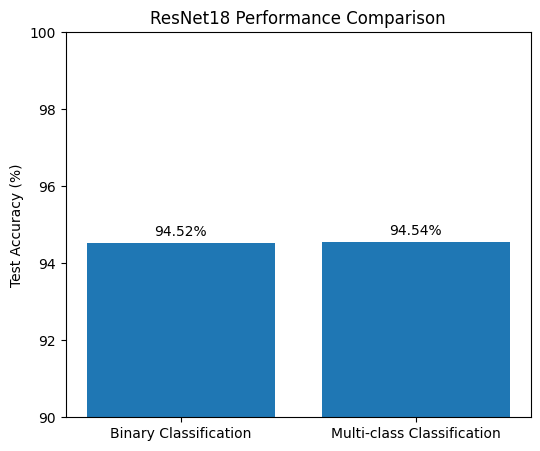

In [ ]:
import matplotlib.pyplot as plt
binary_accuracy = 94.52
multiclass_accuracy = 94.54

models = ['Binary Classification', 'Multi-class Classification']
accuracies = [binary_accuracy, multiclass_accuracy]

plt.figure(figsize=(6,5))

bars = plt.bar(models, accuracies)

plt.ylim(90, 100)
plt.ylabel("Test Accuracy (%)")
plt.title("ResNet18 Performance Comparison")

for i in range(len(accuracies)):
    plt.text(i, accuracies[i] + 0.2,
             f"{accuracies[i]:.2f}%",
             ha='center')

plt.show()
